Analiza jucatorilor de fotbal - sezon 2025/2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Bibliotecile au fost importate cu succes')

Bibliotecile au fost importate cu succes


1. Incarcarea si curatarea datelor

In [2]:
df = pd.read_csv('players_data-2025_2026.csv')
print(f'Datele au fost încărcate. Baza de date are {df.shape[0]} jucători și {df.shape[1]} coloane.')
display(df.head())

Datele au fost încărcate. Baza de date are 2751 jucători și 102 coloane.


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,32,26,...,2,0,0,18,47,5,36,14,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,...,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,26.0,1999.0,7,1,...,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [3]:
print('--- Informații generale ---')
df.info()
print('\n--- Valori lipsă per coloană (top 15) ---')
print(df.isnull().sum()[df.isnull().sum() > 0].head(15))

--- Informații generale ---
<class 'pandas.DataFrame'>
RangeIndex: 2751 entries, 0 to 2750
Columns: 102 entries, Rk to OG
dtypes: float64(41), int64(40), str(21)
memory usage: 2.1 MB

--- Valori lipsă per coloană (top 15) ---
Nation                    2
Age                       1
Born                      1
Rk_stats_keeper        2576
Nation_stats_keeper    2576
Pos_stats_keeper       2576
Comp_stats_keeper      2576
Age_stats_keeper       2576
Born_stats_keeper      2576
MP_stats_keeper        2576
Starts_stats_keeper    2576
Min_stats_keeper       2576
90s_stats_keeper       2576
GA                     2576
GA90                   2576
dtype: int64


In [4]:
# unii jucatori apar cu doua pozitii (ex: "MF,FW"), pastram doar prima
df['Pos'] = df['Pos'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

jucatori_initial = len(df)
df = df[df['Min'] >= 900]
print(f'Am eliminat {jucatori_initial - len(df)} jucători cu prea puține minute jucate.')

# FBref genereaza coloane duplicate la join-uri, le stergem
cols_de_sters = [c for c in df.columns if any(s in c for s in [
    '_stats_keeper', '_stats_shooting', '_stats_playing_time', '_stats_misc'
])]
df = df.drop(columns=cols_de_sters, errors='ignore')
df = df.drop(columns=['Rk'], errors='ignore')
df = df.dropna(subset=['Player', 'Pos', 'Min'])
# Eliminam duplicatele (jucatori transferati apar de 2 ori in FBref)
df = df.sort_values('Min', ascending=False).drop_duplicates(subset='Player', keep='first')

# coloana Nation vine ca "eng ENG", vrem doar "ENG"
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)
df['Comp']   = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)
df['Age']    = df['Age'].astype(float).astype('Int64')
df['Born']   = df['Born'].astype(float).astype('Int64')

print(f'\nBaza de date curățată a rămas cu {len(df)} jucători gata pentru analiză.')
print(f'Distribuție pe poziții:\n{df["Pos"].value_counts()}')

Am eliminat 1334 jucători cu prea puține minute jucate.

Baza de date curățată a rămas cu 1413 jucători gata pentru analiză.
Distribuție pe poziții:
Pos
MF    630
DF    484
FW    190
GK    109
Name: count, dtype: int64


2. Explorarea datelor (EDA)

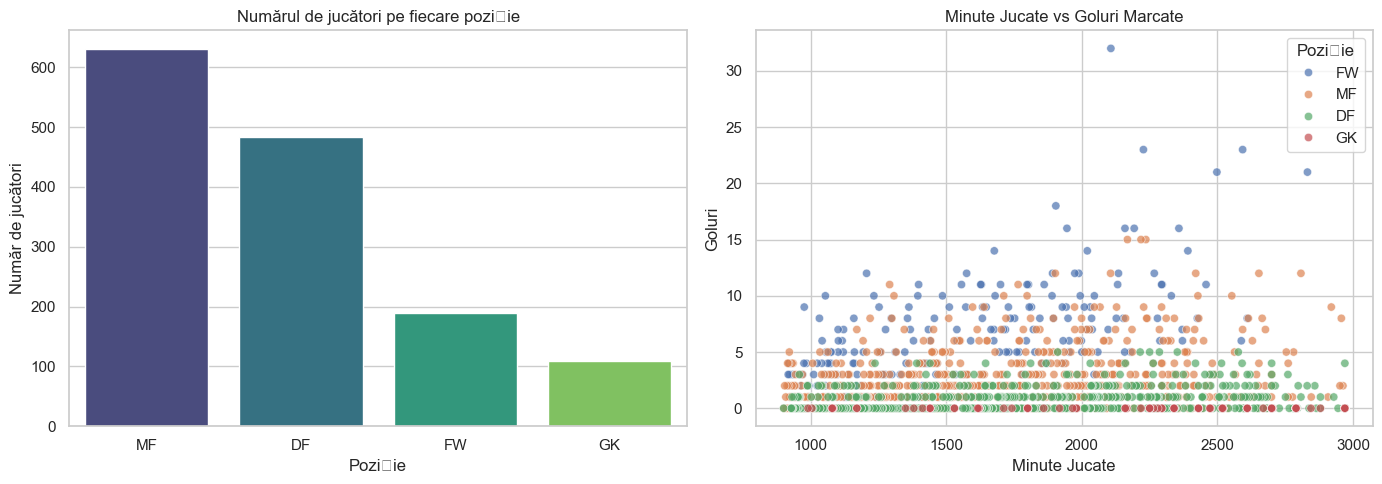

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index,
              palette='viridis', ax=axes[0])
axes[0].set_title('Numărul de jucători pe fiecare poziție')
axes[0].set_xlabel('Poziție')
axes[0].set_ylabel('Număr de jucători')

sns.scatterplot(data=df, x='Min', y='Gls', hue='Pos', alpha=0.7, ax=axes[1])
axes[1].set_title('Minute Jucate vs Goluri Marcate')
axes[1].set_xlabel('Minute Jucate')
axes[1].set_ylabel('Goluri')
axes[1].legend(title='Poziție')

plt.tight_layout()
plt.savefig("grafic_eda.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# 'eng ENG' devine 'ENG'
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)

# 'eng Premier League' devine 'Premier League'
df['Comp'] = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)

df['Age'] = df['Age'].astype(float).astype('Int64')
df['Born'] = df['Born'].astype(float).astype('Int64')

display(df[['Player', 'Nation', 'Comp', 'Age']].head())

,Player,Nation,Comp,Age
2590,Virgil van Dijk,NED,League,34
2619,Bart Verbruggen,NED,League,23
939,David de Gea,ESP,A,35
448,Elia Caprile,ITA,A,24
464,Marco Carnesecchi,ITA,A,25


In [8]:
df.to_csv('players-curatat.csv', index=False)
print("Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.")

Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.


3. Ingineria caracteristicilor

In [9]:
def norm_local(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

_90s = df['90s'].replace(0, np.nan)

# --- Features de baza (calculate pe tot df, per 90) ---
df['Cards_Penalty_90'] = (df['CrdY'].fillna(0) + df['CrdR'].fillna(0) * 3) / _90s
df['Def_Actions_90']   = (df['TklW'].fillna(0) + df['Int'].fillna(0)) / _90s
df['Fls_90']           = df['Fls'].fillna(0) / _90s
df['NonPK_Gls_90']     = df['G-PK'].fillna(0) / _90s
df['Ast_90']           = df['Ast'].fillna(0) / _90s
df['SoT_Rate']         = df['SoT'].fillna(0) / df['Sh'].fillna(1).replace(0, 1)
df['G_per_SoT']        = df['G/SoT'].fillna(0)
df['Off_90']           = df['Off'].fillna(0) / _90s
df['Off_Direct_90']    = (df['G-PK'].fillna(0) + df['Ast'].fillna(0)) / _90s
df['Crs_90']           = df['Crs'].fillna(0) / _90s
df['PlusMinus_90']     = df['+/-90'].fillna(0)
df['OG_penalty']       = df['OG'].fillna(0)
df['Sh_90']            = df['Sh'].fillna(0) / _90s
df['GA90_inv']         = -df['GA90'].fillna(df['GA90'].median())
df['CS_Rate']          = df['CS'].fillna(0) / df['MP'].replace(0, np.nan)
df['PKsv_Rate']        = df['PKsv'].fillna(0) / df['PKA'].replace(0, np.nan).fillna(1).replace(0, 1)

# ============================================================
# SCORURI - fiecare calculat LOCAL pe subsetul pozitiei
# Ponderi bazate pe literatura de football analytics (xG/xA
# sunt cele mai predictive, dar neavandu-le folosim proxy-uri)
# ============================================================

# --- ATACANTI ---
# Sursa: golurile non-PK + assisturi per 90 sunt cei mai buni
# predictori de performanta (analog npxG+xA in literatura).
# G_per_SoT = finishing ability (analog xG overperformance).
# Sh_90 = volum ofensiv, important pentru atacanti dominanti.
# Off_90 penalizat putin - offsideurile ridicate indica
# pozitionare agresiva (nu neaparat negativa).
fw = df[(df['Pos'] == 'FW') & (df['Min'] >= 900)].copy()
fw['Contributie_Ofensiva'] = (
    norm_local(fw['NonPK_Gls_90']) * 0.38 +  # goluri non-pk/90 - cel mai important
    norm_local(fw['Ast_90'])        * 0.22 +  # assisturi/90
    norm_local(fw['G_per_SoT'])     * 0.18 +  # eficienta finalizare
    norm_local(fw['Sh_90'])         * 0.12 +  # volum ofensiv (avantajeaza atacantii dominanti)
    norm_local(fw['Def_Actions_90'])* 0.06 +  # pressing
    norm_local(-fw['Off_90'])       * 0.04    # ofsaid - penalizare mica
)

# --- MIJLOCASI ---
# Sursa: contributia ofensiva directa + defensiva sunt egale
# pentru un midfielder complet (box-to-box).
# Crs_90 = creativitate laterala.
# PlusMinus_90 = impact general cand e pe teren.
mf = df[(df['Pos'] == 'MF') & (df['Min'] >= 900)].copy()
mf['Scor_Playmaker'] = (
    norm_local(mf['Off_Direct_90'])      * 0.28 +  # gls+ast non-pk/90
    norm_local(mf['Def_Actions_90'])     * 0.28 +  # tackle+interceptii/90
    norm_local(mf['PlusMinus_90'])       * 0.18 +  # impact echipa
    norm_local(mf['Crs_90'])             * 0.12 +  # centrari/creativitate
    norm_local(-mf['Cards_Penalty_90'])  * 0.08 +  # disciplina
    norm_local(-mf['Fls_90'])            * 0.06    # fair play
)

# --- FUNDASI ---
# Sursa: actiunile defensive sunt core (tackle+interceptii).
# PlusMinus_90 e important - un fundas bun tine echipa la 0.
# Faulturile frecvente = risc, nu duritate utila.
dff = df[(df['Pos'] == 'DF') & (df['Min'] >= 900)].copy()
dff['Scor_Fundas'] = (
    norm_local(dff['Def_Actions_90'])     * 0.40 +  # tackle+interceptii/90
    norm_local(dff['PlusMinus_90'])       * 0.25 +  # impact echipa
    norm_local(-dff['Cards_Penalty_90'])  * 0.15 +  # disciplina
    norm_local(-dff['Fls_90'])            * 0.10 +  # nu face faulturi inutile
    norm_local(dff['Crs_90'])             * 0.07 +  # fundas lateral modern
    norm_local(-dff['OG_penalty'])        * 0.03    # autogoluri
)

# --- PORTARI ---
# Sursa: Save% si PSxG-GA sunt cei mai buni predictori (neavand
# PSxG, folosim Save% + CS_Rate + GA90 ca proxy complet).
_save_pct = df['Save%'].fillna(df['Save%'].median())
gk = df[(df['Pos'] == 'GK') & (df['Min'] >= 900)].copy()
gk['Scor_Portar'] = (
    norm_local(_save_pct[gk.index])            * 0.40 +  # % salvari - cel mai predictiv
    norm_local(gk['CS_Rate'].fillna(0))        * 0.30 +  # clean sheets rate
    norm_local(gk['GA90_inv'])                 * 0.20 +  # goluri primite/90 (inversat)
    norm_local(gk['PKsv_Rate'].fillna(0))      * 0.10    # penaltyuri salvate
)

# Reunim totul inapoi
df = pd.concat([fw, mf, dff, gk, df[~df['Pos'].isin(['FW','MF','DF','GK'])]])
df = df.reset_index(drop=True)

print("Features create cu succes!")
display(df[['Player', 'Pos', 'Contributie_Ofensiva', 'Scor_Playmaker', 'Scor_Fundas', 'Scor_Portar']].dropna(how='all', subset=['Contributie_Ofensiva','Scor_Playmaker','Scor_Fundas','Scor_Portar']).head(10))

Features create cu succes!


,Player,Pos,Contributie_Ofensiva,Scor_Playmaker,Scor_Fundas,Scor_Portar
0,Igor Thiago,FW,0.377080,NaN,NaN,NaN
1,Mateo Pellegrino,FW,0.284342,NaN,NaN,NaN
2,Erling Haaland,FW,0.632000,NaN,NaN,NaN
3,Issa Soumaré,FW,0.289158,NaN,NaN,NaN
4,Vedat Muriqi,FW,0.446455,NaN,NaN,NaN
5,Ollie Watkins,FW,0.380119,NaN,NaN,NaN
6,Lassine Sinayoko,FW,0.299244,NaN,NaN,NaN
7,João Pedro,FW,0.529142,NaN,NaN,NaN
8,Evanilson,FW,0.246650,NaN,NaN,NaN
9,Ludovic Ajorque,FW,0.457543,NaN,NaN,NaN


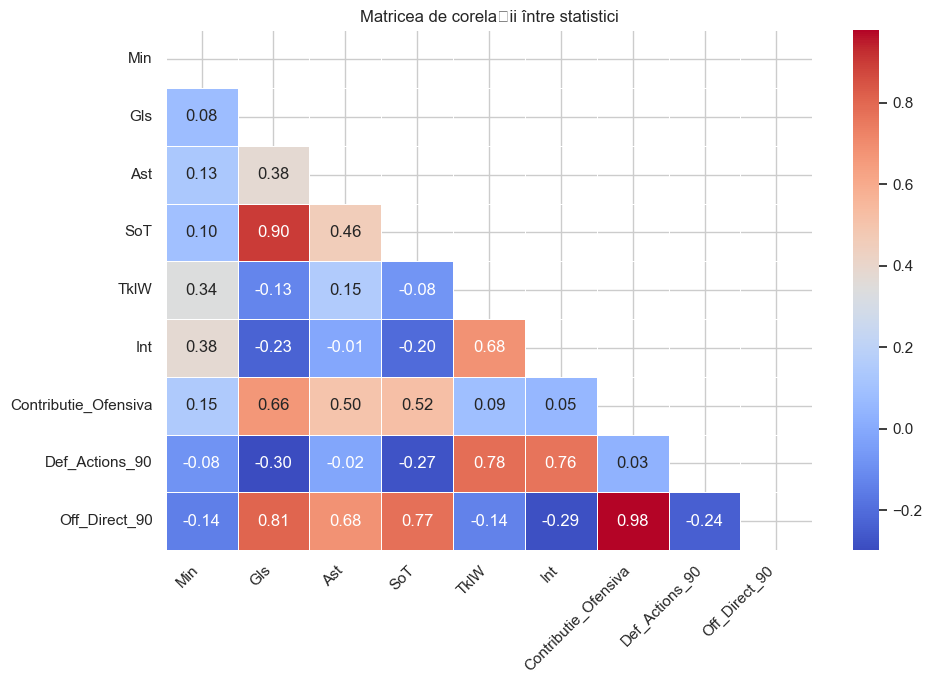

In [25]:
coloane_corr = ['Min', 'Gls', 'Ast', 'SoT', 'TklW', 'Int',
                'Contributie_Ofensiva', 'Def_Actions_90', 'Off_Direct_90']
coloane_corr = [c for c in coloane_corr if c in df.columns]

matrice = df[coloane_corr].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(matrice, dtype=bool))
sns.heatmap(matrice, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Matricea de corelații între statistici')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("grafic_corelatii.png", dpi=150, bbox_inches="tight")
plt.show()

4. Implementare și comparare algoritmi ML

Vom antrena și compara 10 algoritmi pentru fiecare poziție:

    Random Forest
    Gradient Boosting
    Extra Trees
    AdaBoost
    Ridge Regression
    Lasso Regression
    SVR (Support Vector Regression)
    KNN Regression
    Decision Tree
    ElasticNet


In [11]:
def antreneaza_si_compara_modele(df_pos, features, target, pos_name):
    df_clean = df_pos.dropna(subset=[target]).copy()
    X = df_clean[features].fillna(0)
    y = df_clean[target]

    if len(X) < 15:
        print(f'Nu sunt suficienți jucători pentru {pos_name}')
        return None, None

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f'\n{"="*65}')
    print(f'  ANTRENARE MODELE PENTRU: {pos_name}')
    print(f'  Train: {len(X_train)} jucători | Test: {len(X_test)} jucători')
    print(f'{"="*65}')

    configuratii = [
        {
            'nume': 'Random Forest',
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Gradient Boosting',
            'model': GradientBoostingRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Extra Trees',
            'model': ExtraTreesRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'AdaBoost',
            'model': AdaBoostRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 1.0]
            },
            'scaled': False
        },
        {
            'nume': 'Ridge Regression',
            'model': Ridge(),
            'params': {'alpha': [0.01, 0.1, 1, 10, 100]},
            'scaled': True
        },
        {
            'nume': 'Lasso Regression',
            'model': Lasso(),
            'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
            'scaled': True
        },
        {
            'nume': 'ElasticNet',
            'model': ElasticNet(),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'scaled': True
        },
        {
            'nume': 'SVR',
            'model': SVR(),
            'params': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1, 0.5],
                'kernel': ['rbf', 'linear']
            },
            'scaled': True
        },
        {
            'nume': 'KNN Regression',
            'model': KNeighborsRegressor(),
            'params': {
                'n_neighbors': [3, 5, 7, 10],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'scaled': True
        },
        {
            'nume': 'Decision Tree',
            'model': DecisionTreeRegressor(random_state=42),
            'params': {
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'scaled': False
        },
    ]

    rezultate = []
    best_models = {}

    for cfg in configuratii:
        Xtr = X_train_sc if cfg['scaled'] else X_train
        Xte = X_test_sc  if cfg['scaled'] else X_test

        grid = GridSearchCV(cfg['model'], cfg['params'], cv=5,
                            scoring='r2', n_jobs=-1, refit=True)
        grid.fit(Xtr, y_train)
        best = grid.best_estimator_
        y_pred = best.predict(Xte)

        # cv pe train ca sa vedem daca modelul e stabil sau overfittat
        cv_scores = cross_val_score(best, Xtr, y_train, cv=5, scoring='r2')

        mse  = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        rezultate.append({
            'Model': cfg['nume'],
            'R²': round(r2, 4),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'MSE': round(mse, 4),
            'CV R² (mean)': round(cv_scores.mean(), 4),
            'CV R² (std)': round(cv_scores.std(), 4),
            'Best Params': str(grid.best_params_)
        })

        print(f'  ✓ {cfg["nume"]:22s}  R²={r2:+.4f}  RMSE={rmse:.4f}  Params: {grid.best_params_}')
        best_models[cfg['nume']] = {'model': best, 'y_pred': y_pred}

    rez_df = pd.DataFrame(rezultate).sort_values('R²', ascending=False).reset_index(drop=True)
    rez_df.index += 1
    return rez_df, best_models


print('Funcția de antrenare a fost definită!')

Funcția de antrenare a fost definită!


4.1 Modele pentru Atacanți 

In [12]:
df_fw = df[df['Pos'] == 'FW'].copy()

features_fw = [
    'NonPK_Gls_90',     # goluri fara penalty per 90
    'Ast_90',           # assisturi per 90
    'SoT_Rate',         # precizie la sut (SoT/Sh)
    'G_per_SoT',        # goluri per sut pe poarta
    'Def_Actions_90',   # pressing si tackle per 90
    'Off_90',           # offsideuri per 90 (negativ)
    'Cards_Penalty_90', # disciplina (negativ)
    'Age',
]
features_fw = [f for f in features_fw if f in df_fw.columns]

rez_fw, models_fw = antreneaza_si_compara_modele(
    df_fw, features_fw, 'Contributie_Ofensiva', 'FW - ATACANȚI'
)
print('\n--- Tabel Comparativ Rezultate: ATACANȚI ---')
display(rez_fw)



  ANTRENARE MODELE PENTRU: FW - ATACANȚI
  Train: 152 jucători | Test: 38 jucători
  ✓ Random Forest           R²=+0.9316  RMSE=0.0278  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ Gradient Boosting       R²=+0.9568  RMSE=0.0221  Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9453  RMSE=0.0249  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ AdaBoost                R²=+0.9182  RMSE=0.0305  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+0.9962  RMSE=0.0065  Params: {'alpha': 1}
  ✓ Lasso Regression        R²=+0.9954  RMSE=0.0072  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+0.9963  RMSE=0.0065  Params: {'alpha': 0.001, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.9953  RMSE=0.0073  Params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.7767  RMSE=0.0503  Params: {'metric': 'euclidean', 

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,ElasticNet,0.9963,0.0065,0.0052,0.0000,0.9913,0.0038,"{'alpha': 0.001, 'l1_ratio': 0.2}"
2,Ridge Regression,0.9962,0.0065,0.0052,0.0000,0.9914,0.0039,{'alpha': 1}
3,Lasso Regression,0.9954,0.0072,0.0058,0.0001,0.9909,0.0040,{'alpha': 0.001}
4,SVR,0.9953,0.0073,0.0056,0.0001,0.9904,0.0038,"{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}"
5,Gradient Boosting,0.9568,0.0221,0.0168,0.0005,0.9503,0.0105,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
6,Extra Trees,0.9453,0.0249,0.0194,0.0006,0.9634,0.0198,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
7,Random Forest,0.9316,0.0278,0.0201,0.0008,0.9261,0.0201,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
8,AdaBoost,0.9182,0.0305,0.0234,0.0009,0.9163,0.0184,"{'learning_rate': 1.0, 'n_estimators': 200}"
9,Decision Tree,0.8459,0.0418,0.0339,0.0017,0.8544,0.0397,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
10,KNN Regression,0.7767,0.0503,0.0372,0.0025,0.8114,0.0311,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei..."


4.2 Modele pentru Mijlocași

In [13]:
df_mf = df[df['Pos'] == 'MF'].copy()

features_mf = [
    'Off_Direct_90',    # gls+ast fara pk per 90
    'Def_Actions_90',   # tackle + interceptii per 90
    'Crs_90',           # centrari per 90
    'Fls_90',           # faulturi comise per 90 (negativ)
    'Cards_Penalty_90', # disciplina (negativ)
    'PlusMinus_90',     # impact echipa cand e pe teren
    'Age',
]
features_mf = [f for f in features_mf if f in df_mf.columns]

rez_mf, models_mf = antreneaza_si_compara_modele(
    df_mf, features_mf, 'Scor_Playmaker', 'MF - MIJLOCAȘI'
)
print('\n--- Tabel Comparativ Rezultate Brute: MIJLOCAȘI ---')
display(rez_mf)



  ANTRENARE MODELE PENTRU: MF - MIJLOCAȘI
  Train: 504 jucători | Test: 126 jucători
  ✓ Random Forest           R²=+0.8925  RMSE=0.0246  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ Gradient Boosting       R²=+0.9664  RMSE=0.0137  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9128  RMSE=0.0221  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ AdaBoost                R²=+0.8248  RMSE=0.0313  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+1.0000  RMSE=0.0000  Params: {'alpha': 0.01}
  ✓ Lasso Regression        R²=+0.9986  RMSE=0.0028  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+0.9999  RMSE=0.0006  Params: {'alpha': 0.001, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.9963  RMSE=0.0045  Params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.8647  RMSE=0.0275  Params: {'metric': 'eucl

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,Ridge Regression,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,{'alpha': 0.01}
2,ElasticNet,0.9999,0.0006,0.0005,0.0000,0.9999,0.0000,"{'alpha': 0.001, 'l1_ratio': 0.2}"
3,Lasso Regression,0.9986,0.0028,0.0023,0.0000,0.9986,0.0002,{'alpha': 0.001}
4,SVR,0.9963,0.0045,0.0036,0.0000,0.9961,0.0007,"{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}"
5,Gradient Boosting,0.9664,0.0137,0.0099,0.0002,0.9381,0.0126,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
6,Extra Trees,0.9128,0.0221,0.0158,0.0005,0.8940,0.0156,"{'max_depth': None, 'min_samples_split': 2, 'n..."
7,Random Forest,0.8925,0.0246,0.0177,0.0006,0.8597,0.0201,"{'max_depth': None, 'min_samples_split': 2, 'n..."
8,KNN Regression,0.8647,0.0275,0.0210,0.0008,0.8202,0.0182,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei..."
9,AdaBoost,0.8248,0.0313,0.0237,0.0010,0.8025,0.0204,"{'learning_rate': 1.0, 'n_estimators': 200}"
10,Decision Tree,0.7870,0.0346,0.0278,0.0012,0.6851,0.0555,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."


4.3 Modele pentru Fundași 

In [14]:
df_df = df[df['Pos'] == 'DF'].copy()

features_df = [
    'Def_Actions_90',   # tackle + interceptii per 90
    'Fls_90',           # faulturi comise per 90 (negativ)
    'PlusMinus_90',     # impact echipa
    'Crs_90',           # centrari per 90 (lateral modern)
    'Cards_Penalty_90', # disciplina (negativ)
    'OG_penalty',       # autogoluri (penalizare)
    'Age',
]
features_df = [f for f in features_df if f in df_df.columns]

rez_df, models_df = antreneaza_si_compara_modele(
    df_df, features_df, 'Scor_Fundas', 'DF - FUNDAȘI'
)
print('\n--- Tabel Comparativ Rezultate Brute: FUNDAȘI ---')
display(rez_df)



  ANTRENARE MODELE PENTRU: DF - FUNDAȘI
  Train: 387 jucători | Test: 97 jucători
  ✓ Random Forest           R²=+0.8957  RMSE=0.0245  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ Gradient Boosting       R²=+0.9562  RMSE=0.0159  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9328  RMSE=0.0196  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ AdaBoost                R²=+0.8604  RMSE=0.0283  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+1.0000  RMSE=0.0000  Params: {'alpha': 0.01}
  ✓ Lasso Regression        R²=+0.9990  RMSE=0.0024  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+1.0000  RMSE=0.0005  Params: {'alpha': 0.001, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.9976  RMSE=0.0037  Params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.8438  RMSE=0.0300  Params: {'metric': 'euclide

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,ElasticNet,1.0000,0.0005,0.0004,0.0000,1.0000,0.0000,"{'alpha': 0.001, 'l1_ratio': 0.2}"
2,Ridge Regression,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,{'alpha': 0.01}
3,Lasso Regression,0.9990,0.0024,0.0018,0.0000,0.9991,0.0002,{'alpha': 0.001}
4,SVR,0.9976,0.0037,0.0029,0.0000,0.9971,0.0005,"{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}"
5,Gradient Boosting,0.9562,0.0159,0.0114,0.0003,0.9513,0.0138,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
6,Extra Trees,0.9328,0.0196,0.0139,0.0004,0.9233,0.0282,"{'max_depth': None, 'min_samples_split': 2, 'n..."
7,Random Forest,0.8957,0.0245,0.0172,0.0006,0.8961,0.0305,"{'max_depth': None, 'min_samples_split': 2, 'n..."
8,AdaBoost,0.8604,0.0283,0.0213,0.0008,0.8336,0.0330,"{'learning_rate': 1.0, 'n_estimators': 200}"
9,KNN Regression,0.8438,0.0300,0.0228,0.0009,0.8180,0.0127,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei..."
10,Decision Tree,0.7479,0.0380,0.0302,0.0014,0.7753,0.0374,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."


4.4 Modele pentru Portari 

In [15]:
df_gk = df[df['Pos'] == 'GK'].copy()

features_gk = [
    'Save%',        # procentaj salvari
    'CS_Rate',      # rata clean sheets
    'GA90_inv',     # goluri primite per 90 (inversat)
    'PKsv_Rate',    # penaltyuri salvate
    'SoTA',         # volum de munca (suturi pe poarta infruntat)
    'Age',
]
features_gk = [f for f in features_gk if f in df_gk.columns]

rez_gk, models_gk = antreneaza_si_compara_modele(
    df_gk, features_gk, 'Scor_Portar', 'GK - PORTARI'
)
print('\n--- Tabel Comparativ Rezultate Brute: PORTARI ---')
display(rez_gk)



  ANTRENARE MODELE PENTRU: GK - PORTARI
  Train: 87 jucători | Test: 22 jucători
  ✓ Random Forest           R²=+0.9345  RMSE=0.0364  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ Gradient Boosting       R²=+0.9257  RMSE=0.0388  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9611  RMSE=0.0281  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ AdaBoost                R²=+0.9023  RMSE=0.0445  Params: {'learning_rate': 1.0, 'n_estimators': 50}
  ✓ Ridge Regression        R²=+1.0000  RMSE=0.0000  Params: {'alpha': 0.01}
  ✓ Lasso Regression        R²=+0.9998  RMSE=0.0018  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+1.0000  RMSE=0.0004  Params: {'alpha': 0.001, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.9989  RMSE=0.0046  Params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.9111  RMSE=0.0425  Params: {'metric': 'manhattan', '

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,ElasticNet,1.0000,0.0004,0.0003,0.0000,1.0000,0.0000,"{'alpha': 0.001, 'l1_ratio': 0.2}"
2,Ridge Regression,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,{'alpha': 0.01}
3,Lasso Regression,0.9998,0.0018,0.0013,0.0000,0.9999,0.0001,{'alpha': 0.001}
4,SVR,0.9989,0.0046,0.0041,0.0000,0.9983,0.0014,"{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}"
5,Extra Trees,0.9611,0.0281,0.0200,0.0008,0.9501,0.0310,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
6,Random Forest,0.9345,0.0364,0.0261,0.0013,0.9242,0.0368,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
7,Gradient Boosting,0.9257,0.0388,0.0297,0.0015,0.9357,0.0494,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
8,KNN Regression,0.9111,0.0425,0.0363,0.0018,0.8725,0.0516,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei..."
9,AdaBoost,0.9023,0.0445,0.0338,0.0020,0.8794,0.0705,"{'learning_rate': 1.0, 'n_estimators': 50}"
10,Decision Tree,0.8326,0.0583,0.0475,0.0034,0.7931,0.0710,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s..."


5. Vizualizare comparativă modele

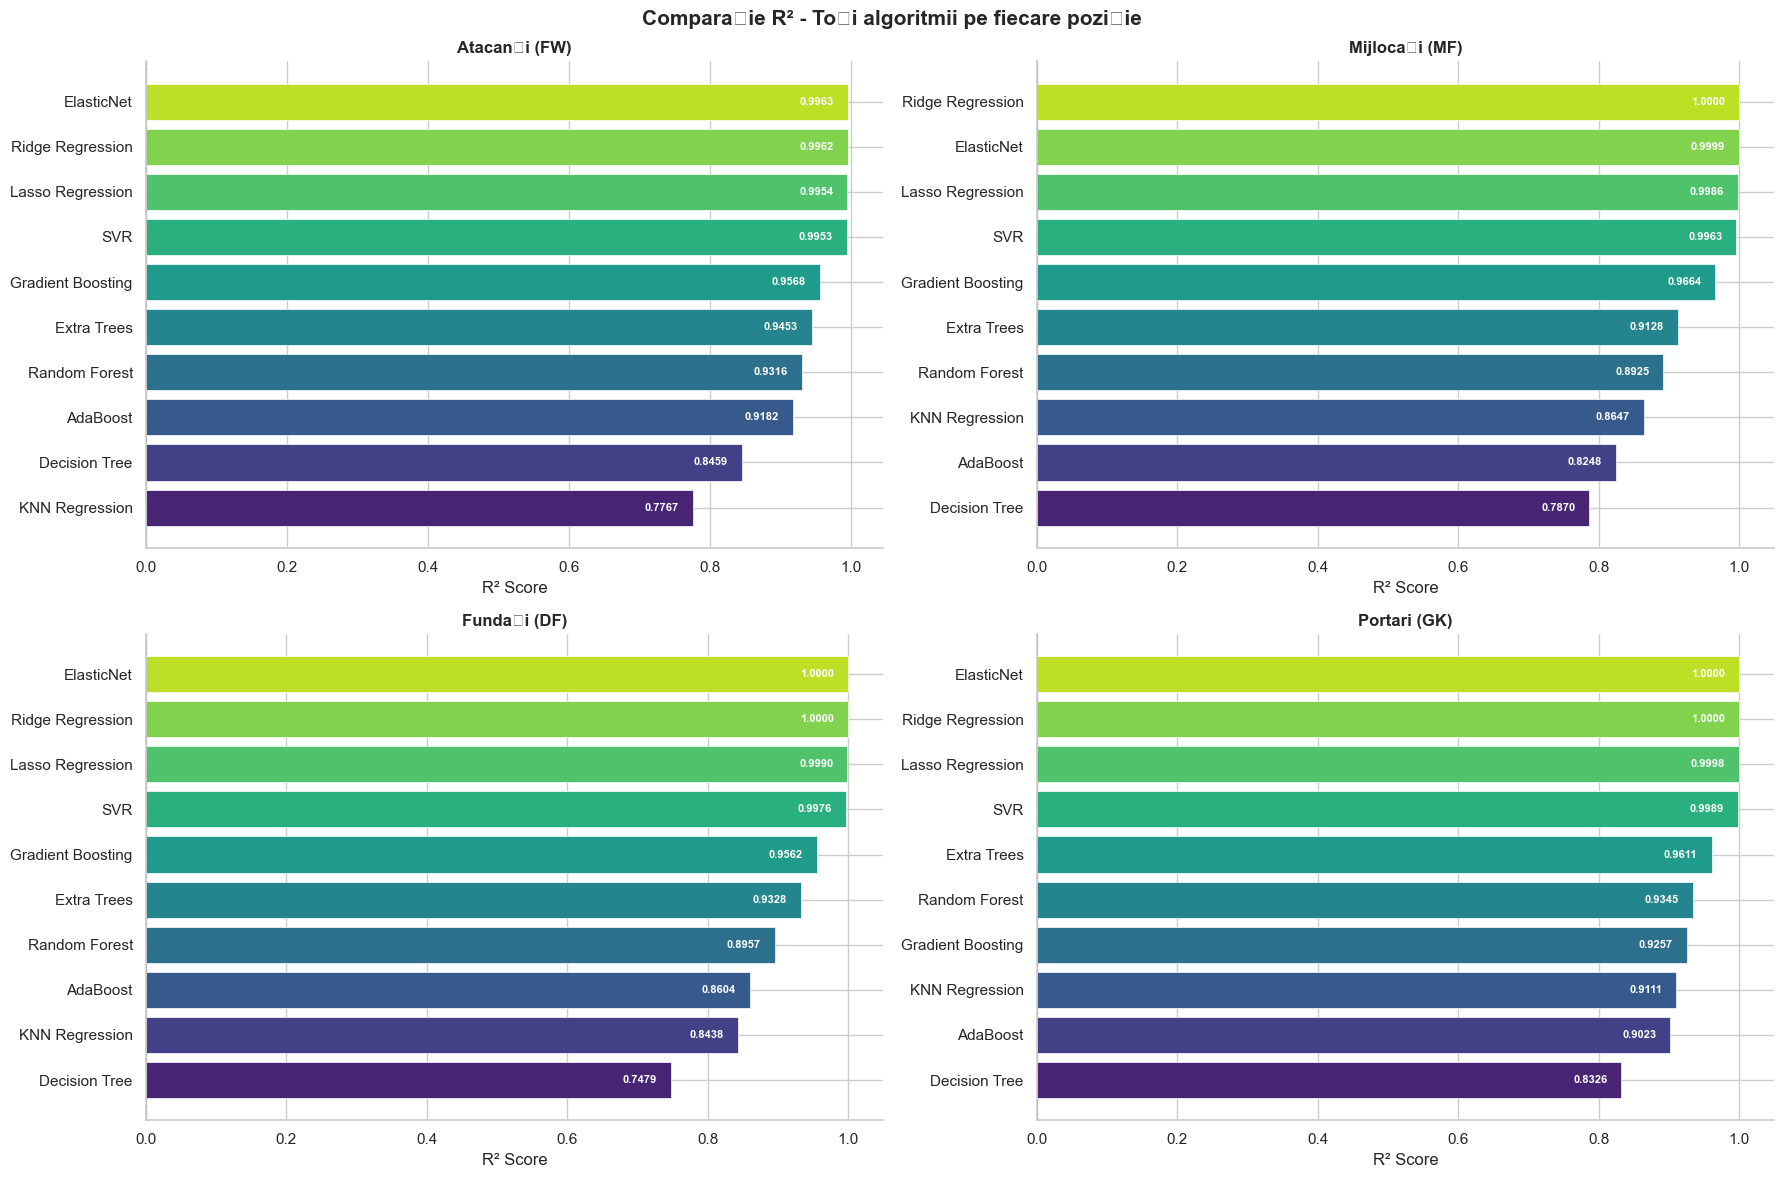

In [26]:
def plot_comparatie_modele(rez_dict):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Comparație R² - Toți algoritmii pe fiecare poziție', fontsize=15, fontweight='bold')

    culori = plt.cm.viridis(np.linspace(0.1, 0.9, 10))

    for ax, (pos_name, rez) in zip(axes.flatten(), rez_dict.items()):
        if rez is None:
            ax.set_visible(False)
            continue
        rez_sorted = rez.sort_values('R²')
        bars = ax.barh(rez_sorted['Model'], rez_sorted['R²'],
                       color=culori[:len(rez_sorted)], edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, rez_sorted['R²']):
            ax.text(max(val - 0.02, 0.01), bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', ha='right', fontsize=8,
                    color='white', fontweight='bold')
        ax.set_title(pos_name, fontsize=12, fontweight='bold')
        ax.set_xlabel('R² Score')
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig("grafic_r2_algoritmi.png", dpi=150, bbox_inches="tight")
    plt.show()


rez_dict = {
    'Atacanți (FW)':  rez_fw,
    'Mijlocași (MF)': rez_mf,
    'Fundași (DF)':   rez_df,
    'Portari (GK)':   rez_gk,
}

plot_comparatie_modele(rez_dict)

In [17]:
print('\n=== CEL MAI BUN MODEL PE FIECARE POZIȚIE ===')
rezumat = []
for pos_name, rez in rez_dict.items():
    if rez is not None:
        top = rez.iloc[0]
        rezumat.append({
            'Poziție': pos_name,
            'Cel mai bun model': top['Model'],
            'R²': top['R²'],
            'RMSE': top['RMSE'],
            'MAE': top['MAE'],
            'CV R² (mean)': top['CV R² (mean)'],
        })
display(pd.DataFrame(rezumat))


=== CEL MAI BUN MODEL PE FIECARE POZIȚIE ===


,Poziție,Cel mai bun model,R²,RMSE,MAE,CV R² (mean)
0,Atacanți (FW),ElasticNet,0.9963,0.0065,0.0052,0.9913
1,Mijlocași (MF),Ridge Regression,1.0000,0.0000,0.0000,1.0000
2,Fundași (DF),ElasticNet,1.0000,0.0005,0.0004,1.0000
3,Portari (GK),ElasticNet,1.0000,0.0004,0.0003,1.0000


6. Top 5 jucători pe fiecare poziție¶

In [18]:
criterii = {
    'GK': 'Scor_Portar',
    'DF': 'Scor_Fundas',
    'MF': 'Scor_Playmaker',
    'FW': 'Contributie_Ofensiva',
}

coloane_afisare = {
    'GK': ['Player', 'Squad', 'Comp', 'Age', 'Save%', 'CS_Rate', 'GA90_inv', 'PKsv_Rate', 'Scor_Portar'],
    'DF': ['Player', 'Squad', 'Comp', 'Age', 'Def_Actions_90', 'Fls_90', 'PlusMinus_90', 'Cards_Penalty_90', 'Scor_Fundas'],
    'MF': ['Player', 'Squad', 'Comp', 'Age', 'Off_Direct_90', 'Def_Actions_90', 'Crs_90', 'PlusMinus_90', 'Scor_Playmaker'],
    'FW': ['Player', 'Squad', 'Comp', 'Age', 'NonPK_Gls_90', 'Ast_90', 'SoT_Rate', 'G_per_SoT', 'Contributie_Ofensiva'],
}

pozitii_label = {
    'GK': 'Portari',
    'DF': 'Fundași',
    'MF': 'Mijlocași',
    'FW': 'Atacanți',
}

top5_toate = {}
for pos, criteriu in criterii.items():
    df_pos = df[df['Pos'] == pos].copy()
    cols   = [c for c in coloane_afisare[pos] if c in df_pos.columns]
    top5   = df_pos.nlargest(5, criteriu, keep='all')[cols].reset_index(drop=True)
    top5.index += 1
    top5_toate[pos] = top5
    print(f'\n=== 🏆 Top 5 {pozitii_label[pos]} (scor compozit per 90 min) ===')
    display(top5)



=== 🏆 Top 5 Portari (scor compozit per 90 min) ===


,Player,Squad,Comp,Age,Save%,CS_Rate,GA90_inv,PKsv_Rate,Scor_Portar
1,Joan García,Barcelona,Liga,24,79.5,0.480000,-0.76,0.000000,0.872000
2,Marco Carnesecchi,Atalanta,A,25,77.4,0.363636,-0.88,2.000000,0.859963
3,Mike Maignan,Milan,A,30,79.4,0.406250,-0.85,0.400000,0.839141
4,Lucas Chevalier,Paris Saint-Germain,1,24,72.1,0.529412,-0.76,1.000000,0.832072
5,Ivan Provedel,Lazio,A,32,78.6,0.444444,-1.00,0.333333,0.828913



=== 🏆 Top 5 Fundași (scor compozit per 90 min) ===


,Player,Squad,Comp,Age,Def_Actions_90,Fls_90,PlusMinus_90,Cards_Penalty_90,Scor_Fundas
1,Malang Sarr,Lens,1,27,3.642857,0.571429,1.07,0.071429,0.748407
2,Kim Min-jae,Bayern Munich,,29,2.875817,0.588235,2.29,0.065359,0.716976
3,Maximilian Mittelstädt,Stuttgart,,29,3.254717,0.471698,0.71,0.141509,0.714582
4,Eric García,Barcelona,Liga,25,3.153846,1.192308,1.89,0.153846,0.693818
5,Gabriel Suazo,Sevilla,Liga,28,4.090909,1.363636,-0.40,0.340909,0.691773



=== 🏆 Top 5 Mijlocași (scor compozit per 90 min) ===


,Player,Squad,Comp,Age,Off_Direct_90,Def_Actions_90,Crs_90,PlusMinus_90,Scor_Playmaker
1,Michael Olise,Bayern Munich,,24,1.282051,1.068376,5.555556,2.61,0.651928
2,Federico Dimarco,Inter,A,28,0.735294,2.169118,9.963235,1.73,0.640363
3,Serge Gnabry,Bayern Munich,,30,1.037037,1.037037,1.555556,2.51,0.581270
4,Luis Díaz,Bayern Munich,,29,1.129032,1.129032,1.612903,2.70,0.567366
5,Lennart Karl,Bayern Munich,,18,0.671642,1.716418,1.865672,2.54,0.558970



=== 🏆 Top 5 Atacanți (scor compozit per 90 min) ===


,Player,Squad,Comp,Age,NonPK_Gls_90,Ast_90,SoT_Rate,G_per_SoT,Contributie_Ofensiva
1,Deniz Undav,Stuttgart,,29,0.849057,0.283019,0.390909,0.42,0.745917
2,Harry Kane,Bayern Munich,,32,0.940171,0.213675,0.563636,0.35,0.723691
3,Pavel Šulc,Lyon,1,25,0.709677,0.193548,0.390244,0.69,0.664076
4,Lautaro Martínez,Inter,A,28,0.740741,0.185185,0.406977,0.46,0.641051
5,Erling Haaland,Manchester City,League,25,0.694444,0.243056,0.459459,0.39,0.632000


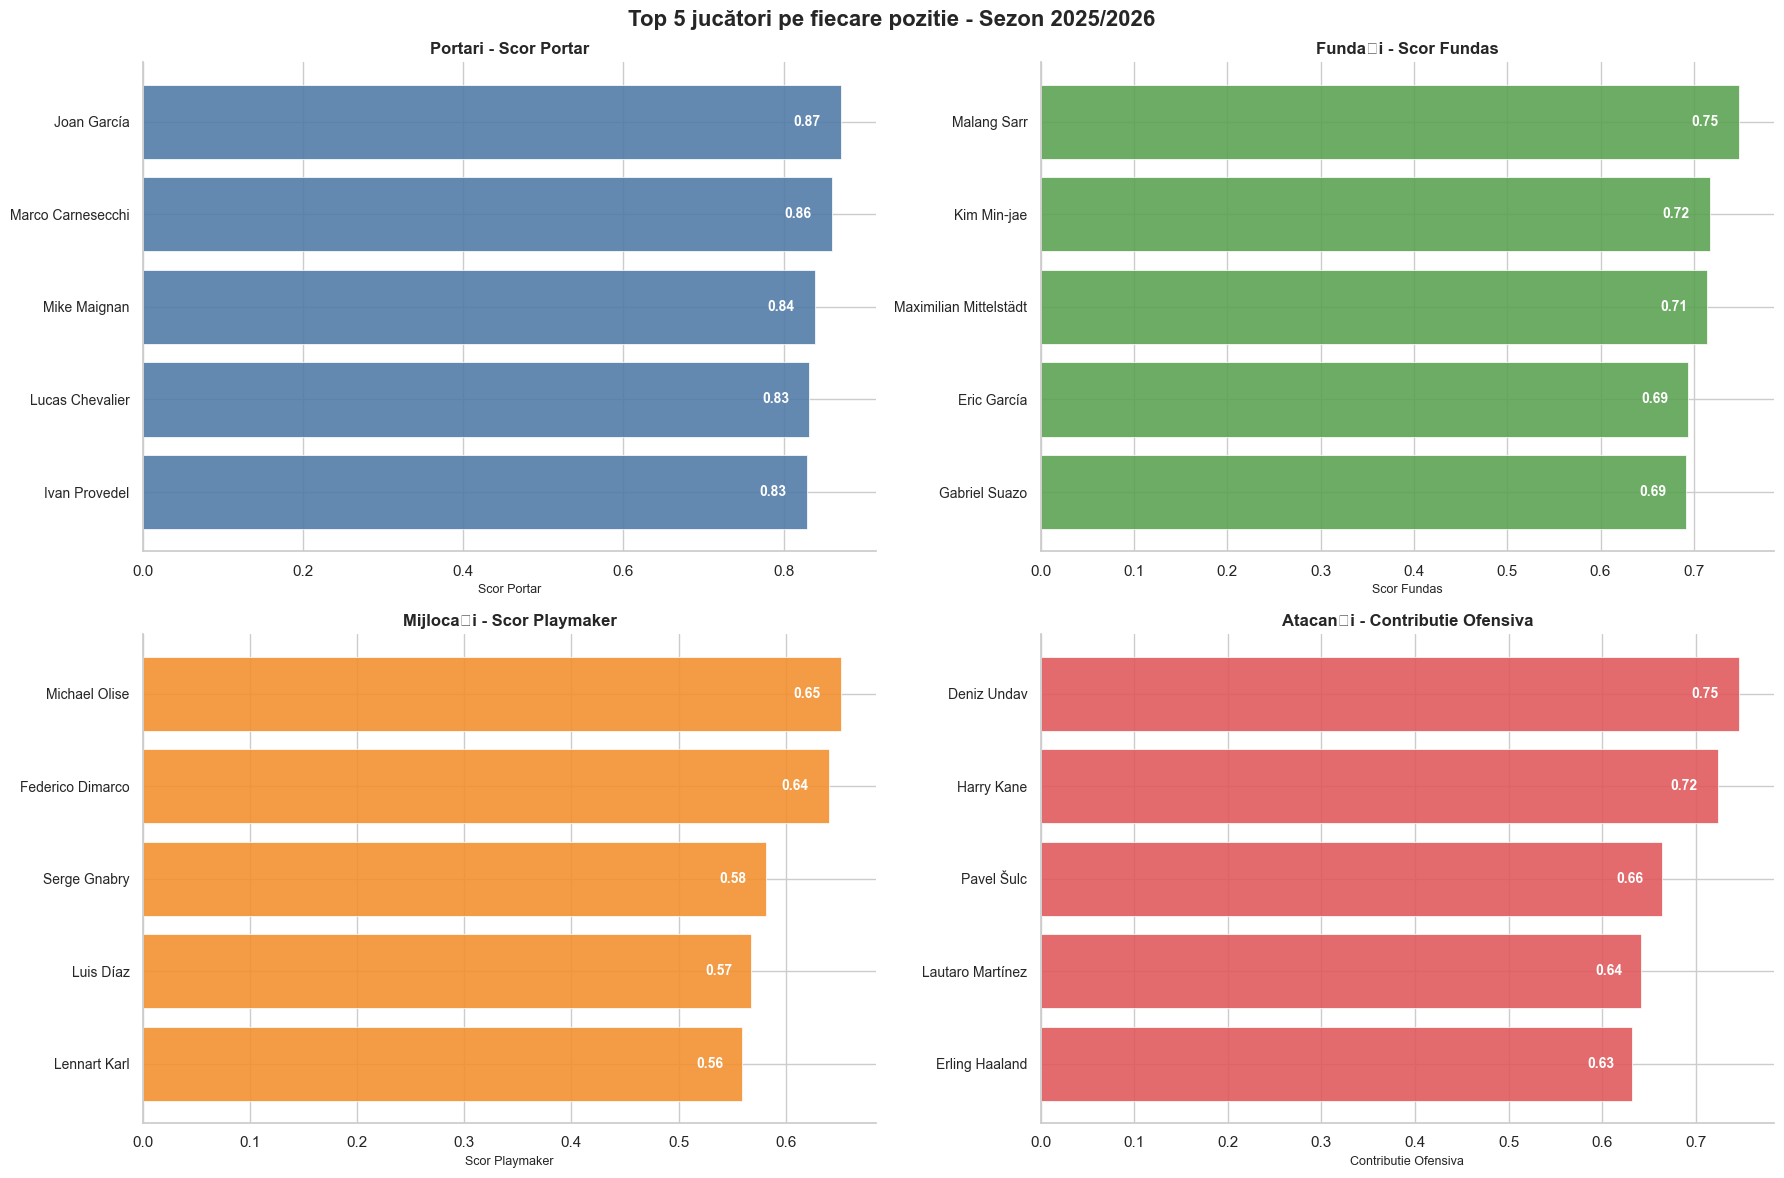

In [27]:
# Vizualizare Top 5 pe toate pozițiile
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top 5 jucători pe fiecare pozitie - Sezon 2025/2026',
             fontsize=16, fontweight='bold')

culori_pos = {'GK': '#4e79a7', 'DF': '#59a14f', 'MF': '#f28e2b', 'FW': '#e15759'}

for ax, (pos, criteriu) in zip(axes.flatten(), criterii.items()):
    df_pos = df[df['Pos'] == pos].copy()
    top5   = df_pos.nlargest(5, criteriu)[['Player', criteriu]].reset_index(drop=True)

    bars = ax.barh(top5['Player'][::-1], top5[criteriu][::-1],
                   color=culori_pos[pos], alpha=0.88, edgecolor='white', linewidth=0.6)

    for bar, val in zip(bars, top5[criteriu][::-1]):
        ax.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='right', fontsize=10,
                color='white', fontweight='bold')

    ax.set_title(f'{pozitii_label[pos]} - {criteriu.replace("_", " ")}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(criteriu.replace('_', ' '), fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig("grafic_top5.png", dpi=150, bbox_inches="tight")
plt.show()

7. Feature Importance – cel mai bun model pe fiecare poziție

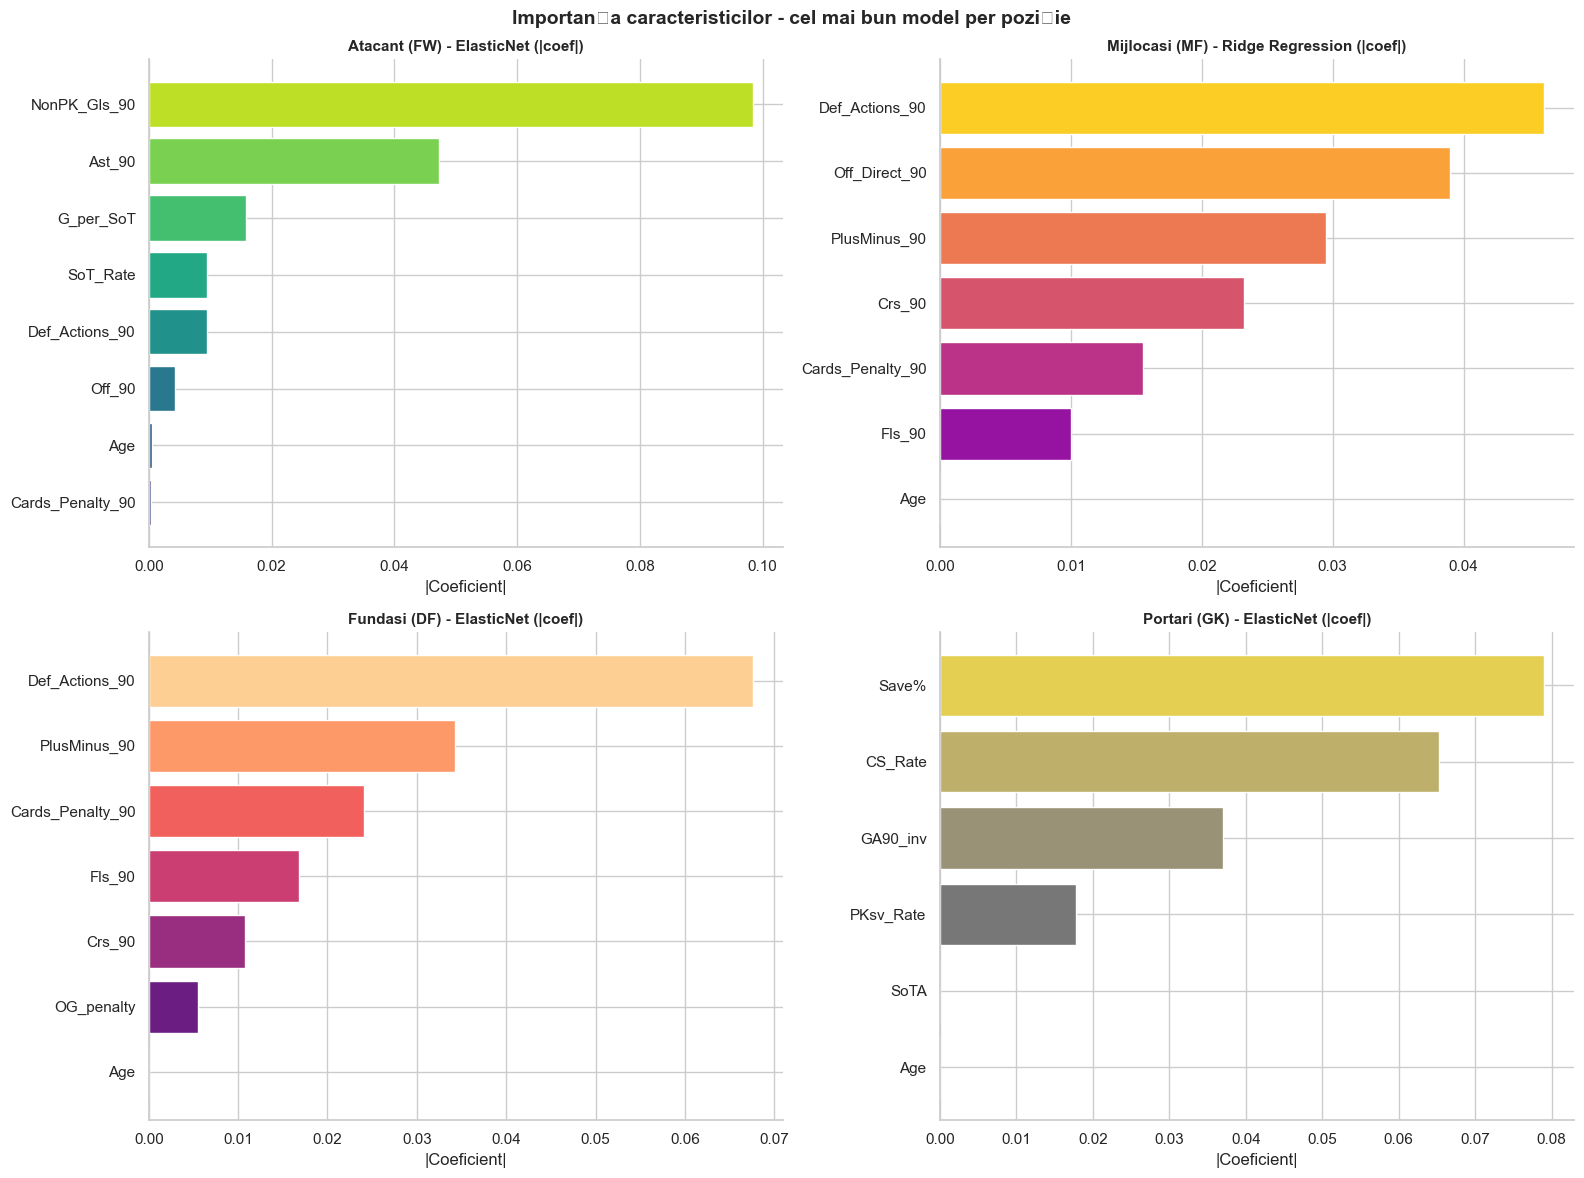

In [ ]:
def plot_feature_importance(model, features, title, ax, color='viridis'):
    """Afișează importanța caracteristicilor dacă modelul o suportă."""
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({'Caracteristică': features,
                            'Importanță': model.feature_importances_})
        imp = imp.sort_values('Importanță', ascending=True)
        ax.barh(imp['Caracteristică'], imp['Importanță'],
                color=plt.cm.get_cmap(color)(np.linspace(0.2, 0.9, len(imp))))
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Importanță')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        imp = pd.DataFrame({'Caracteristică': features, 'Importanță': coef})
        imp = imp.sort_values('Importanță', ascending=True)
        ax.barh(imp['Caracteristică'], imp['Importanță'],
                color=plt.cm.get_cmap(color)(np.linspace(0.2, 0.9, len(imp))))
        ax.set_title(title + ' (|coef|)', fontsize=11, fontweight='bold')
        ax.set_xlabel('|Coeficient|')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'Feature importance\nnu este disponibilă',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Importanța caracteristicilor - cel mai bun model per poziție',
             fontsize=14, fontweight='bold')

config_importance = [
    (rez_fw, models_fw, features_fw, 'Atacant (FW)', 'viridis', axes[0, 0]),
    (rez_mf, models_mf, features_mf, 'Mijlocasi (MF)', 'plasma', axes[0, 1]),
    (rez_df, models_df, features_df, 'Fundasi (DF)', 'magma', axes[1, 0]),
    (rez_gk, models_gk, features_gk, 'Portari (GK)', 'cividis', axes[1, 1]),
]

for rez, models, feats, label, cmap, ax in config_importance:
    if rez is not None:
        best_name = rez.iloc[0]['Model']
        best_model = models[best_name]['model']
        plot_feature_importance(best_model, feats, f'{label} - {best_name}', ax, cmap)

plt.tight_layout()
plt.savefig("grafic_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

8. Salvarea rezultatelor

In [21]:
# Salvăm rezultatele brute ale tuturor modelelor
with pd.ExcelWriter('rezultate_brute_modele.xlsx') as writer:
    for pos_name, rez in rez_dict.items():
        if rez is not None:
            sheet = pos_name.replace('(', '').replace(')', '').replace(' ', '_')[:31]
            rez.to_excel(writer, sheet_name=sheet, index=True)

# Salvăm top 5 jucători per poziție
with pd.ExcelWriter('top5_jucatori_pozitii.xlsx') as writer:
    for pos, top5 in top5_toate.items():
        top5.to_excel(writer, sheet_name=pozitii_label[pos], index=True)

# Salvăm și CSV-ul final
df.to_csv('players-final.csv', index=False)

print('✅ Fișierele au fost salvate:')
print('   - rezultate_brute_modele.xlsx  (R², RMSE, MAE, CV scores pentru toți algoritmii)')
print('   - top5_jucatori_pozitii.xlsx   (Top 5 jucători pe fiecare poziție)')
print('   - players-final.csv            (setul de date complet cu toate feature-urile)')

✅ Fișierele au fost salvate:
   - rezultate_brute_modele.xlsx  (R², RMSE, MAE, CV scores pentru toți algoritmii)
   - top5_jucatori_pozitii.xlsx   (Top 5 jucători pe fiecare poziție)
   - players-final.csv            (setul de date complet cu toate feature-urile)
